---
title: "Лабораторна робота 6. Метод головних компонент. Метричні методи класифікації"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "04.20.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: закріпити на практиці концепцію байєсівського вивода засобами мови Python

## Завдання для самостійної роботи 

1. Імопртувати декілька власних довільних зображень, вклчаючи і власне фото.
2. Стиснути його в 20, 30, 50 разів, як показано в прикладах. ВИвести і прокоментувати результати.
3. Побудувати kNN-класифікатор згідно з заданим варіантом без використання віонних функцій і з використанням вікна Парзена. Проаналізувати результати.
4. Дати відповіді на контрольні запитання.
5. Відправити результати роботи у файлі lab_6_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

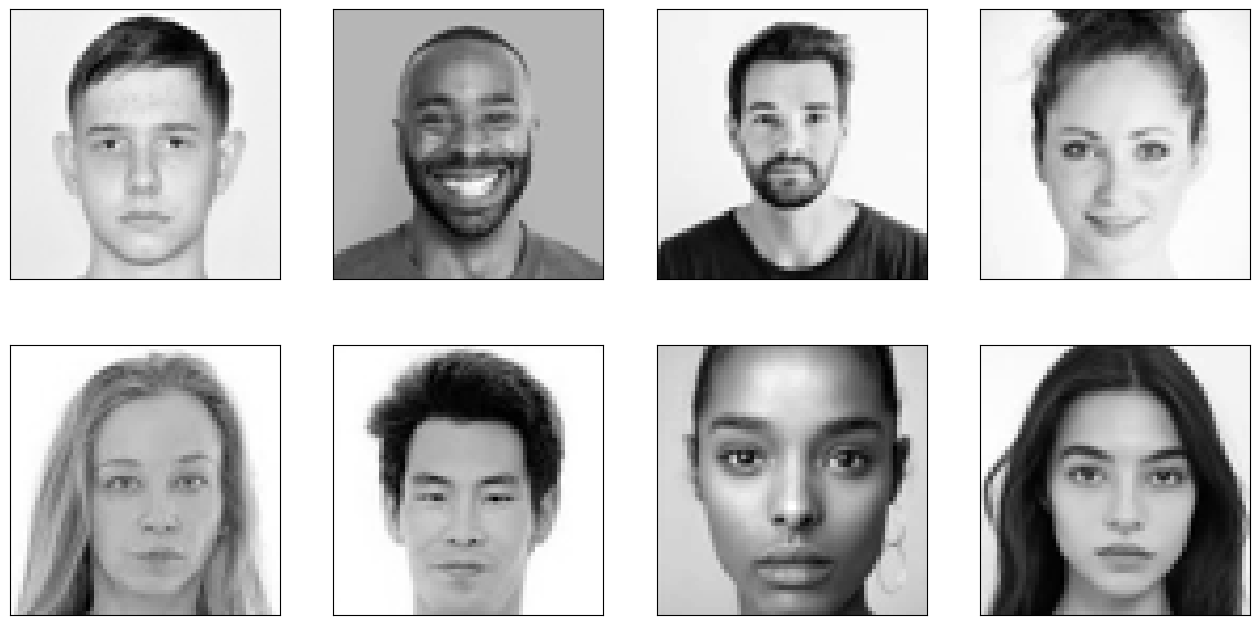

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Шлях до папки з власними зображеннями
data_dir = "Lab_6/"

image_shape = (64, 64)

images = []
labels = []

# Завантаження зображень
for idx, file in enumerate(os.listdir(data_dir)):
    file_path = os.path.join(data_dir, file)
    
    try:
        img = Image.open(file_path).convert('L')  # grayscale
        img = img.resize(image_shape)             # resize до 64x64
        img_array = np.array(img).flatten() / 255.0  # нормалізація
        
        images.append(img_array)
        labels.append(idx)
        
    except Exception as e:
        print(f"Помилка при завантаженні {file}: {e}")

faces_images = np.array(images)
faces_ids = np.array(labels)

# Відображення тільки зображень
plt.figure(figsize=(16, 8))
rows, cols = 2, 4
n_samples = rows * cols

for i in range(min(n_samples, len(faces_images))):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(faces_images[i].reshape(image_shape), cmap='gray')
    plt.xticks(())
    plt.yticks(())

plt.show()

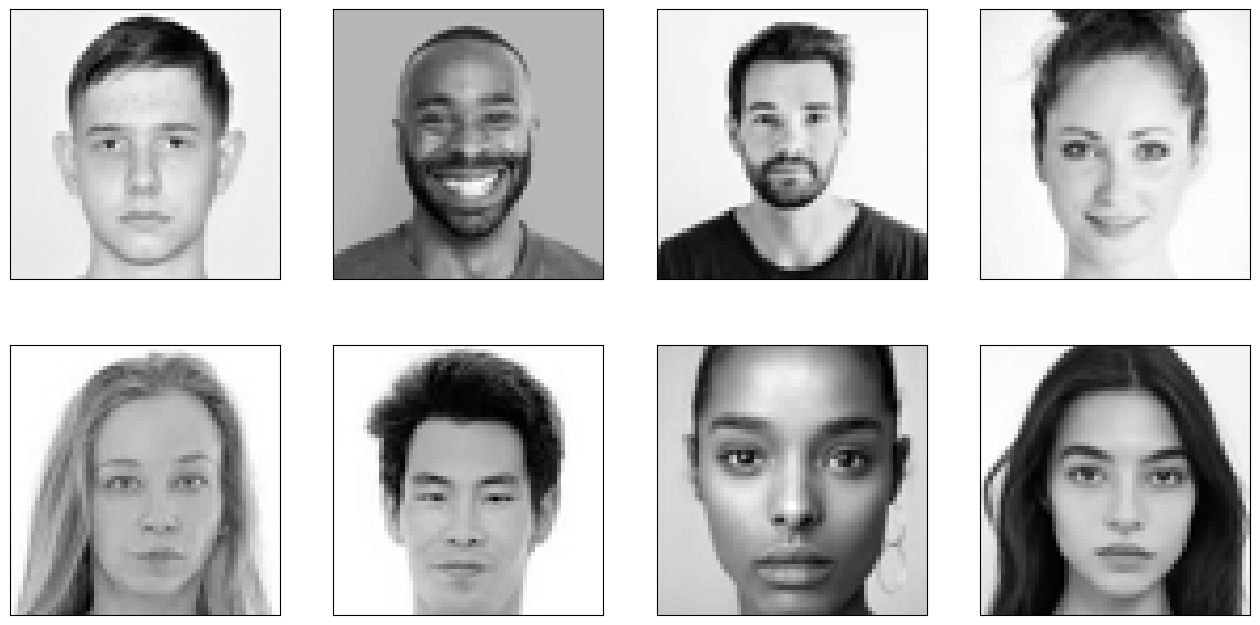

In [2]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

base_size = image_shape[0] * image_shape[1]

def compress_and_show(compress_ratio):
    n_components = int(base_size * compress_ratio)

    # Обмеження (щоб не було помилки)
    n_components = min(n_components, len(faces_images))

    model_pca = PCA(n_components=n_components)
    model_pca.fit(faces_images)

    faces_compressed = model_pca.transform(faces_images)

    # Відновлення
    faces_restored = model_pca.inverse_transform(faces_compressed)

    # Відображення
    plt.figure(figsize=(16, 8))
    rows, cols = 2, 4
    n_samples = rows * cols

    for i in range(min(n_samples, len(faces_restored))):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(faces_restored[i].reshape(image_shape),
                   interpolation='none', cmap='gray')
        plt.xticks(())
        plt.yticks(())

    plt.show()
    
compress_and_show(0.05)


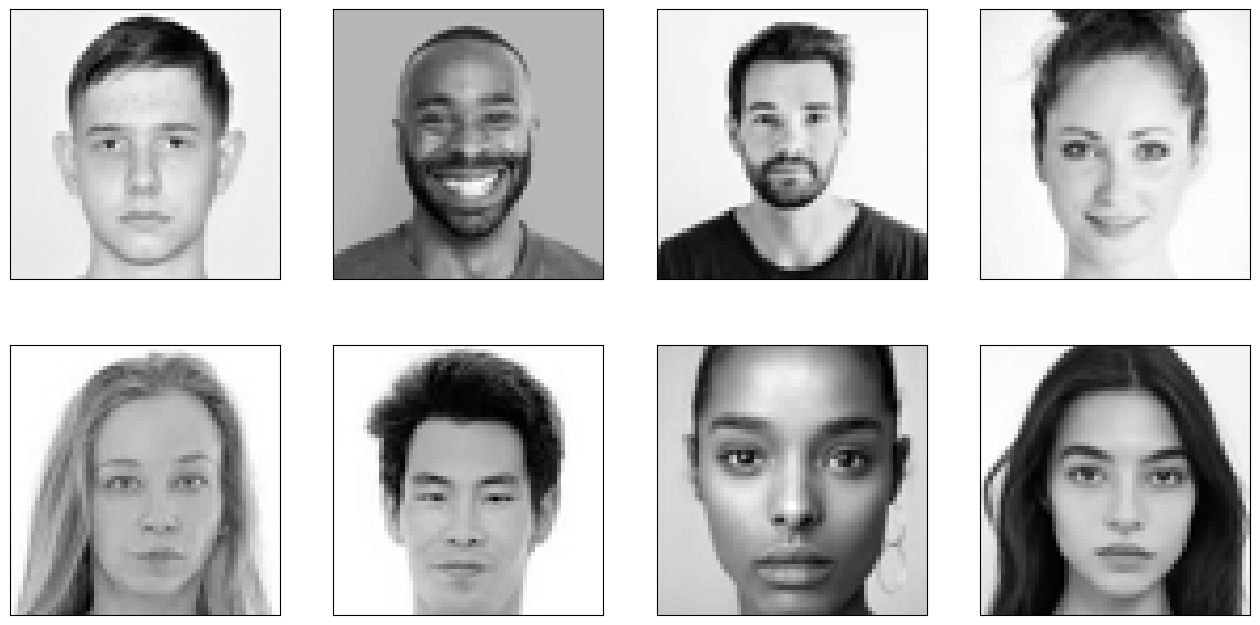

In [3]:
compress_and_show(0.033)

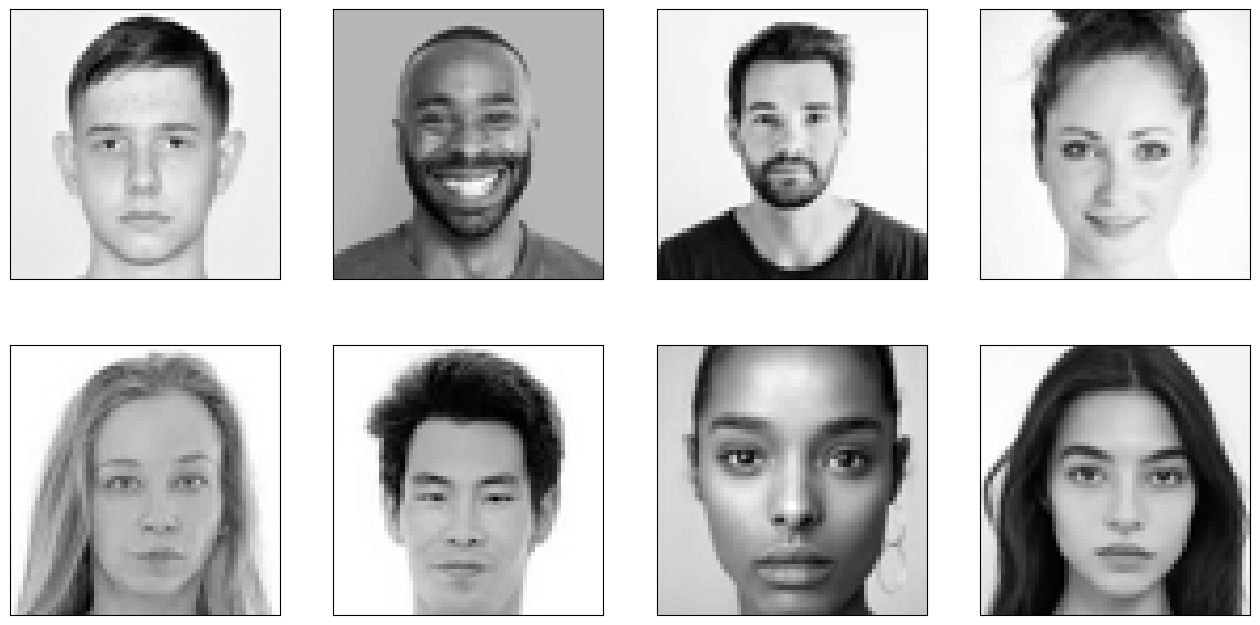

In [4]:
compress_and_show(0.02)

### kNN-класифікатор

Точність класифікації методом k найближчих сусідів: 1.00
Таблиця частот точності класифікації:
--------------------------------------------------
| Клас | Правильно класифіковано | Неправильно класифіковано |
--------------------------------------------------
|  -1  |             3             |              0               |
|  1  |             3             |              0               |
--------------------------------------------------


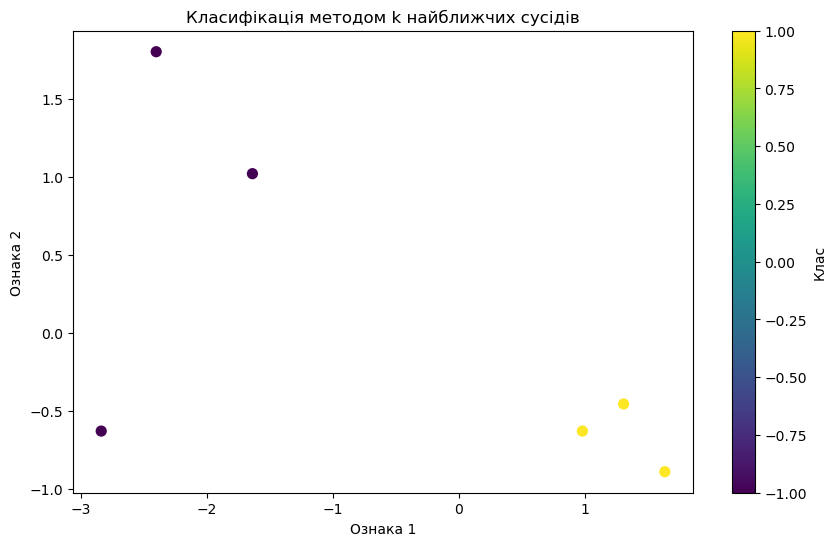

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X = np.array([[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]])
y = np.array([-1, 1, 1, -1, -1, -1, 1, -1, 1, 1])

# Розділення даних на навчальний та тестувальний набори
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

# Нормалізація даних
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Визначення класифікатора та навчання моделі
k = 3  # Кількість найближчих сусідів
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Прогнозування класів для тестових даних
y_pred = knn.predict(X_test)

# Оцінка точності класифікації
accuracy = accuracy_score(y_test, y_pred)
print(f"Точність класифікації методом k найближчих сусідів: {accuracy:.2f}")

# Вивід таблиці частот точності класифікації
print("Таблиця частот точності класифікації:")
print("--------------------------------------------------")
print("| Клас | Правильно класифіковано | Неправильно класифіковано |")
print("--------------------------------------------------")
for target in np.unique(y_test):
    correct = np.sum((y_test == target) & (y_pred == target))
    incorrect = np.sum((y_test == target) & (y_pred != target))
    print(f"|  {target}  | {correct:^25} | {incorrect:^28} |")
print("--------------------------------------------------")

# Візуалізація
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', s=50)
plt.title('Класифікація методом k найближчих сусідів')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.colorbar(label='Клас')
plt.show()

h=0.1 -> точність: 1.00
h=0.5 -> точність: 1.00
h=1.0 -> точність: 1.00


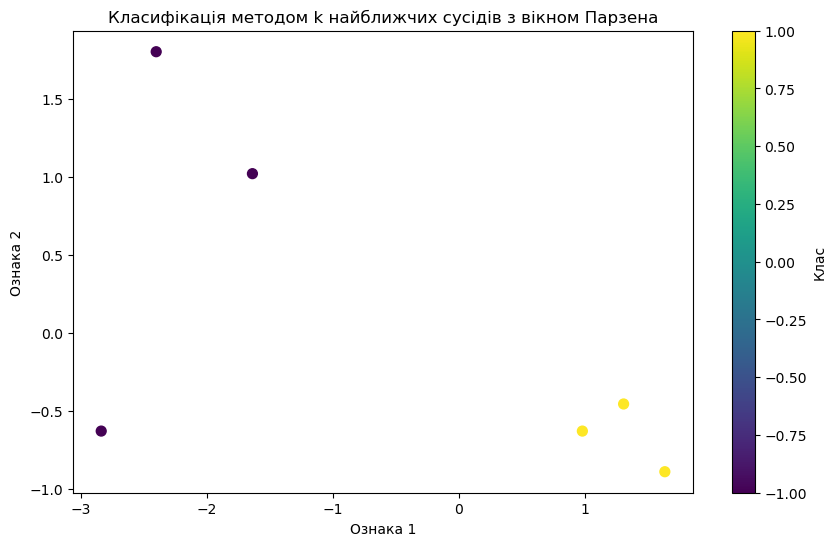

In [10]:
# Ядро Парзена
def parzen_weights(distances, h):
    return np.exp(-(distances**2) / (2 * h**2))  # гаусівське ядро

# Нормалізація даних
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Визначення параметрів моделі
k = 3 # Кількість найближчих сусідів
h_values = [0.1, 0.5, 1.0] # Різні значення вікна Парзена

# Навчання та оцінка моделей для різних значень вікна Парзена
for h in h_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights=lambda distances: parzen_weights(distances, h)
    )
    
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"h={h} -> точність: {accuracy:.2f}")

# Візуалізація
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', s=50)
plt.title('Класифікація методом k найближчих сусідів з вікном Парзена')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.colorbar(label='Клас')
plt.show()